# 61 — Debug `31_07_2026_gastronorm_exp1`

We trained on this dataset and the model predicted **nothingness** (all-zero mask) for every
sample. This notebook loads the whole dataset into a dataframe and checks:

1. **Signal & target statistics** — mean/std of the clean FFT and of the mask, per sample.
   Are they actually *different* across samples, or is everything the empty box?
2. **Splitting / MDS conversion bugs** — does `gastronorm()` assign every sample? Does
   `convert_to_mds` round-trip the metadata the split relies on?

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))

from model.dataset import (
    collect_samples, gastronorm, split_by_position, hash_samples,
    process_vibration, tokenize, normalize_fft, extract_signal,
)

DATA_DIR = Path.cwd().parent / "experiments" / "31_07_2026_gastronorm_exp1"
SAMPLE_DIR = DATA_DIR / "samples"
OUT_H = OUT_W = 30
PATCH_SIZE = 256

pd.set_option("display.width", 200, "display.max_columns", 60)
print(DATA_DIR, DATA_DIR.exists())

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/home/ethantu/workspace/good-vibrations/experiments/31_07_2026_gastronorm_exp1 True


## 0. Load every sample into a dataframe

One row per sample directory, with the metadata plus lazily-computed signal/target stats.

In [2]:
samples = collect_samples(SAMPLE_DIR, verbose=1)
print(f"{len(samples)} complete samples")

collecting samples: 100%|██████████| 3008/3008 [00:01<00:00, 2242.17it/s]

Found 3007 complete samples (1 skipped)
missing 'vibration/03_fft.npz': ['000009']
3007 complete samples


In [3]:
SCALAR_KEYS = [
    "sample_id", "position_id", "speaker", "box", "n_objects", "layout",
    "is_empty_box", "laser_idx", "min_freq", "max_freq", "fps", "power",
    "n_rows", "n_cols", "use_PC",
]

rows = []
for sample_dir, meta in samples:
    row = {k: meta.get(k) for k in SCALAR_KEYS}
    row["dir"] = sample_dir
    row["avg_com"] = meta.get("avg_com")
    row["n_coms"] = len(meta.get("coms", [[]])[0]) if meta.get("coms") else 0
    rows.append(row)

df = pd.DataFrame(rows)
df["sample_id_int"] = df["sample_id"].astype(int)
df = df.sort_values("sample_id_int").reset_index(drop=True)
print(df.shape)
df.head()

(3007, 19)


,sample_id,position_id,speaker,box,n_objects,layout,is_empty_box,laser_idx,min_freq,max_freq,fps,power,n_rows,n_cols,use_PC,dir,avg_com,n_coms,sample_id_int
0,000010,2,2,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,10
1,000011,2,3,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,11
2,000012,2,4,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,12
3,000013,2,5,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,13
4,000014,2,6,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,14


### Which metadata fields does the pipeline actually rely on?

`convert_to_mds` writes a fixed set of columns and `gastronorm` splits on `layout` /
`position_id`. Check what is present vs. what defaults to a sentinel.

In [4]:
all_keys = set()
for _, meta in samples: all_keys |= set(meta)
mds_wants = ["sample_id", "output_id", "n_objects", "speaker", "box", "is_empty_box", "object", "downsampled_com"]
split_wants = ["layout", "position_id"]
for k in mds_wants + split_wants:
    present = sum(k in meta for _, meta in samples)
    print(f"{k:>20}: present in {present}/{len(samples)} samples")

           sample_id: present in 3007/3007 samples
           output_id: present in 0/3007 samples
           n_objects: present in 3007/3007 samples
             speaker: present in 3007/3007 samples
                 box: present in 3007/3007 samples
        is_empty_box: present in 3007/3007 samples
              object: present in 0/3007 samples
     downsampled_com: present in 0/3007 samples
              layout: present in 3007/3007 samples
         position_id: present in 3007/3007 samples


## 1. Mean / std of the clean FFT and of the mask, across all samples

"Clean" = no augmentation, exactly the `augment_fft=0` path the eval loaders use:
`|fft| -> normalize(std) -> tokenize(256)`. We record stats both **pre-** and
**post-** normalization, since the normalization is what the model actually sees.

In [5]:
def sample_stats(sample_dir: Path) -> dict:
    import torch

    d = np.load(sample_dir / "vibration/03_fft.npz")
    fft, freqs = d["fft"], d["freqs"]
    if fft.ndim == 4 and fft.shape[0] == 1: fft = fft[0]          # (L, F, C)
    mag = np.abs(fft)

    x = torch.from_numpy(fft).unsqueeze(0)                         # (1, L, F, C)
    clean = process_vibration(x, torch.from_numpy(freqs), "magnitude", "std", PATCH_SIZE, augment=0.0)
    clean = clean.squeeze(0).numpy()                               # (L, P, PS, C)

    y = np.load(sample_dir / f"images/04_downsampled_smask_{OUT_H}h_{OUT_W}w.npy")

    return {
        # raw complex fft magnitude, before any normalization
        "raw_mag_mean": mag.mean(), "raw_mag_std": mag.std(), "raw_mag_max": mag.max(),
        # what the model is fed
        "fft_mean": clean.mean(), "fft_std": clean.std(),
        "fft_min": clean.min(), "fft_max": clean.max(),
        # the target mask
        "y_mean": y.mean(), "y_std": y.std(), "y_max": y.max(),
        "y_frac_nonzero": float((y > 0).mean()),
        "y_sum": float(y.sum()),
        "n_lasers": fft.shape[0], "n_freqs": fft.shape[1], "n_channels": fft.shape[-1],
        "fft_shape": tuple(clean.shape),
    }

In [6]:
from tqdm.auto import tqdm

stats = [sample_stats(d) for d in tqdm(df["dir"], desc="stats")]
df = pd.concat([df, pd.DataFrame(stats, index=df.index)], axis=1)
df.to_parquet(Path.cwd() / "61_gastronorm_stats.parquet") if False else None
df.head()

stats:   0%|          | 0/3007 [00:00<?, ?it/s]

,sample_id,position_id,speaker,box,n_objects,layout,is_empty_box,laser_idx,min_freq,max_freq,fps,power,n_rows,n_cols,use_PC,dir,avg_com,n_coms,sample_id_int,raw_mag_mean,raw_mag_std,raw_mag_max,fft_mean,fft_std,fft_min,fft_max,y_mean,y_std,y_max,y_frac_nonzero,y_sum,n_lasers,n_freqs,n_channels,fft_shape
0,000010,2,2,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,10,0.761170,1.806082,39.427856,0.502713,1.080419,0.000151,21.830563,0.0,0.0,0.0,0.0,0.0,100,1235,2,"(100, 4, 256, 2)"
1,000011,2,3,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,11,0.480612,1.310175,36.993202,0.436164,1.085248,0.000189,28.235264,0.0,0.0,0.0,0.0,0.0,100,1235,2,"(100, 4, 256, 2)"
2,000012,2,4,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,12,0.490163,1.393937,35.989555,0.419127,1.085972,0.000091,25.818581,0.0,0.0,0.0,0.0,0.0,100,1235,2,"(100, 4, 256, 2)"
3,000013,2,5,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,13,0.236417,0.590690,16.580349,0.472997,1.083916,0.000125,28.069399,0.0,0.0,0.0,0.0,0.0,100,1235,2,"(100, 4, 256, 2)"
4,000014,2,6,gastronorm,0,empty-box,True,55,50,1000,2500,440.9,10,10,False,/home/ethantu/workspace/good-vibrations/experi...,[-1 -1],1,14,0.188221,0.427796,13.413072,0.517077,1.082104,0.000428,31.353859,0.0,0.0,0.0,0.0,0.0,100,1235,2,"(100, 4, 256, 2)"


### Are the FFTs actually different across samples?

If every sample were "the empty box" / a constant tensor, `fft_mean` and `raw_mag_mean` would
be near-identical across rows and the across-sample std would collapse to ~0.

In [7]:
sig_cols = ["raw_mag_mean", "raw_mag_std", "raw_mag_max", "fft_mean", "fft_std", "fft_min", "fft_max"]
summary = df[sig_cols].describe().T
summary["cv_across_samples"] = summary["std"] / summary["mean"].abs()
summary

,count,mean,std,min,25%,50%,75%,max,cv_across_samples
raw_mag_mean,3007.0,0.412532,0.204038,0.098062,0.226880,0.364877,0.628646,1.108210,0.494599
raw_mag_std,3007.0,1.039203,0.546256,0.274167,0.520077,0.995973,1.526758,3.270470,0.525649
raw_mag_max,3007.0,27.976913,13.380291,4.711626,15.708002,27.938042,39.880953,100.511162,0.478262
fft_mean,3007.0,0.488652,0.063705,0.328344,0.437107,0.489863,0.519063,0.715421,0.130369
fft_std,3007.0,1.082681,0.003624,1.067823,1.080702,1.082467,1.085697,1.090592,0.003347
fft_min,3007.0,0.000219,0.000147,0.000004,0.000111,0.000185,0.000289,0.001010,0.672908
fft_max,3007.0,28.019457,5.184048,13.633949,23.748499,27.757385,31.412364,44.191628,0.185016


`cv_across_samples` is the coefficient of variation *between* samples. A value well above ~0.05
means the samples genuinely differ. A value near 0 for `raw_mag_mean` would mean every recording
is effectively the same signal — the "all the same empty box" failure mode.

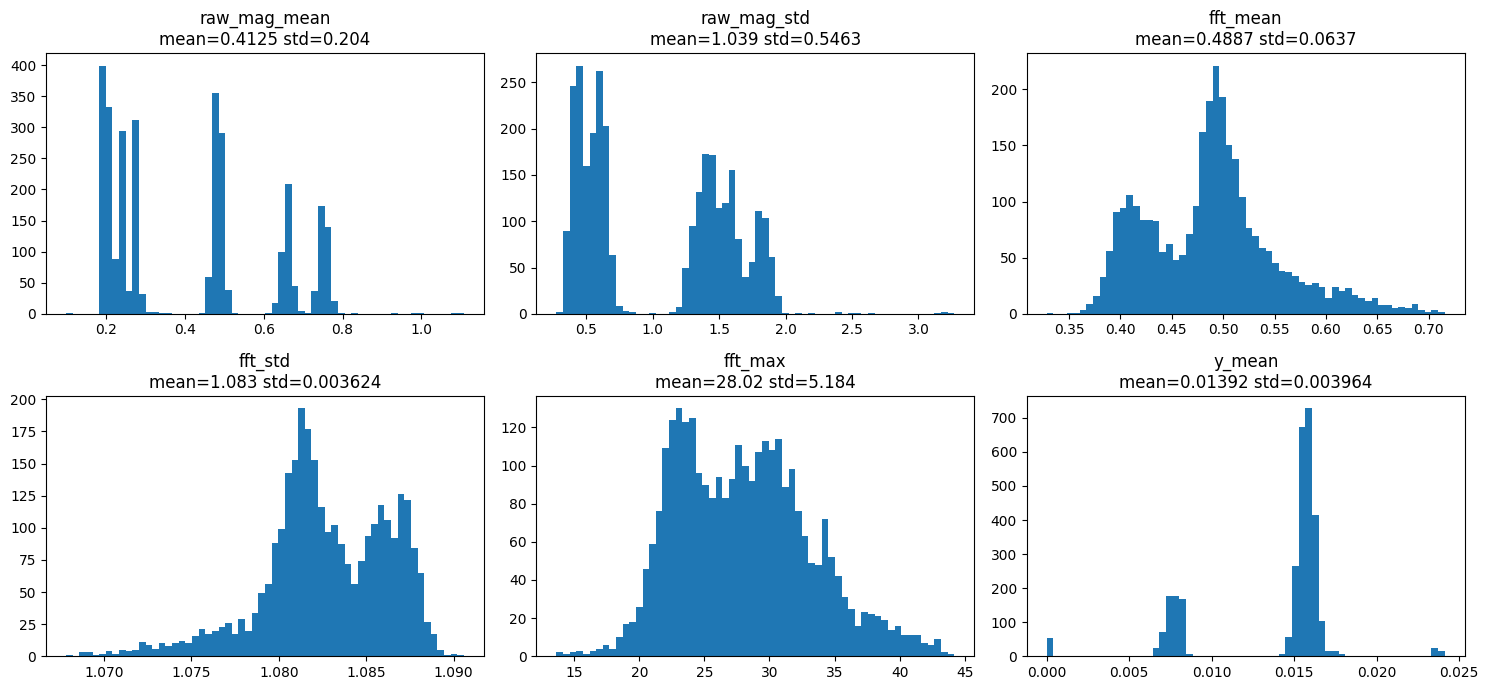

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), ["raw_mag_mean", "raw_mag_std", "fft_mean", "fft_std", "fft_max", "y_mean"]):
    ax.hist(df[c], bins=60)
    ax.set_title(f"{c}\nmean={df[c].mean():.4g} std={df[c].std():.4g}")
plt.tight_layout()

### Signal stats grouped by layout and by speaker

The layouts are the thing the model must distinguish. If `raw_mag_mean` is identical across
layouts but varies wildly across speakers, the FFT carries speaker identity and not object
position.

In [9]:
by_layout = df.groupby("layout")[["raw_mag_mean", "fft_std", "y_mean", "y_frac_nonzero"]].agg(["mean", "std", "count"])
by_layout

raw_mag_mean                   fft_std                    y_mean                 y_frac_nonzero                
                                 mean       std count      mean       std count      mean       std count           mean       std count
layout                                                                                                                                  
empty-box                    0.403997  0.208366    31  1.081021  0.003924    31  0.000000  0.000000    31       0.000000  0.000000    31
lid-purple-cube              0.501357  0.272580    48  1.083479  0.004457    48  0.003776  0.003820    48       0.007407  0.007634    48
purple--green-cube-grid1     0.407175  0.202014   560  1.082727  0.003571   560  0.015778  0.000471   560       0.030095  0.002755   560
purple--green-cube-grid2     0.411809  0.202516   560  1.082589  0.003820   560  0.015840  0.000495   560       0.030016  0.002909   560
purple--green-cube-grid3     0.414377  0.202819   560  1.083133  0.003396   560  0.015830  0.000494   560       0.029730  0.003114   560
purple--green-cube-grid4     0.413308  0.201962   480  1.082941  0.003496   480  0.015750  0.000491   480       0.029481  0.002713   480
purple--green-red-cube       0.414218  0.203478    40  1.083843  0.002964    40  0.023693  0.000292    40       0.042889  0.001962    40
purple-cube                  0.407658  0.203012   560  1.081833  0.003657   560  0.007655  0.000418   560       0.014143  0.001841   560
red-cube                     0.412952  0.205383    40  1.082342  0.003890    40  0.008348  0.000133    40       0.015778  0.002063    40
x-shift                      0.418100  0.207832    72  1.082770  0.003305    72  0.015004  0.000327    72       0.027284  0.002306    72
y-shift                      0.416871  0.204356    56  1.084395  0.002754    56  0.015841  0.000190    56       0.033016  0.002219    56

In [10]:
by_speaker = df.groupby("speaker")[["raw_mag_mean", "fft_std", "y_mean"]].agg(["mean", "std", "count"])
by_speaker

raw_mag_mean                   fft_std                    y_mean                
                mean       std count      mean       std count      mean       std count
speaker                                                                                 
1           0.661039  0.034423   375  1.081279  0.001025   375  0.013949  0.003916   375
2           0.754912  0.025786   376  1.081261  0.001087   376  0.013912  0.003976   376
3           0.479772  0.025291   376  1.086643  0.001188   376  0.013912  0.003976   376
4           0.492102  0.023149   376  1.086543  0.001120   376  0.013912  0.003976   376
5           0.237734  0.009638   376  1.083799  0.002369   376  0.013912  0.003976   376
6           0.195037  0.009582   376  1.083919  0.002267   376  0.013912  0.003976   376
7           0.275041  0.007877   376  1.081014  0.002142   376  0.013912  0.003976   376
8           0.205277  0.013567   376  1.076985  0.003500   376  0.013912  0.003976   376

**Variance decomposition**: how much of the between-sample variance in the signal is explained
by speaker vs. by layout vs. by position? If speaker dominates, the model has an easy nuisance
variable and a hard signal.

In [11]:
def var_explained(df, col, by):
    grand = df[col].var()
    within = df.groupby(by)[col].transform("mean")
    return (within.var() / grand) if grand > 0 else np.nan

for col in ["raw_mag_mean", "fft_std"]:
    for by in ["speaker", "layout", "position_id"]:
        print(f"{col:>14} ~ {by:>12}: {var_explained(df, col, by):6.1%} of between-sample variance")

  raw_mag_mean ~      speaker:  99.0% of between-sample variance
  raw_mag_mean ~       layout:   0.3% of between-sample variance
  raw_mag_mean ~  position_id:   0.7% of between-sample variance
       fft_std ~      speaker:  69.1% of between-sample variance
       fft_std ~       layout:   2.3% of between-sample variance
       fft_std ~  position_id:  15.0% of between-sample variance


### Are the *masks* different across samples?

This is the other half of the question. `y_mean` is the fraction of the 30x30 grid covered by
objects. **This is the number that explains an all-zero prediction under MSE.**

In [12]:
y_cols = ["y_mean", "y_std", "y_max", "y_frac_nonzero", "y_sum"]
df[y_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
y_mean,3007.0,0.013917,0.003964,0.0,0.014907,0.015611,0.016004,0.024125
y_std,3007.0,0.100240,0.019462,0.0,0.102093,0.107591,0.110524,0.133141
y_max,3007.0,0.981709,0.134023,0.0,1.000000,1.000000,1.000000,1.000000
y_frac_nonzero,3007.0,0.026238,0.007953,0.0,0.026667,0.028889,0.031111,0.044444
y_sum,3007.0,12.525286,3.567930,0.0,13.416258,14.049904,14.403310,21.712530


In [13]:
print(f"mean mask occupancy        : {df.y_mean.mean():.4f}")
print(f"MSE of predicting all-zeros: {(df.y_mean ** 2 + df.y_std ** 2).mean():.6f}  (== E[y^2])")
print(f"MSE of predicting the mean : {df.y_std.pow(2).mean():.6f}")
print()
print("A constant-zero predictor already gets essentially the same loss as a constant-mean")
print("predictor when occupancy is this low -- the all-zero solution is a strong local optimum.")

mean mask occupancy        : 0.0139
MSE of predicting all-zeros: 0.010636  (== E[y^2])
MSE of predicting the mean : 0.010427

A constant-zero predictor already gets essentially the same loss as a constant-mean
predictor when occupancy is this low -- the all-zero solution is a strong local optimum.


### Do different positions actually produce different masks?

Average the masks within each layout. If the objects really move around, the per-layout mean
mask should be diffuse; if every sample in a layout has the object in the same place, it will
be a sharp blob (and there is nothing position-dependent to learn).

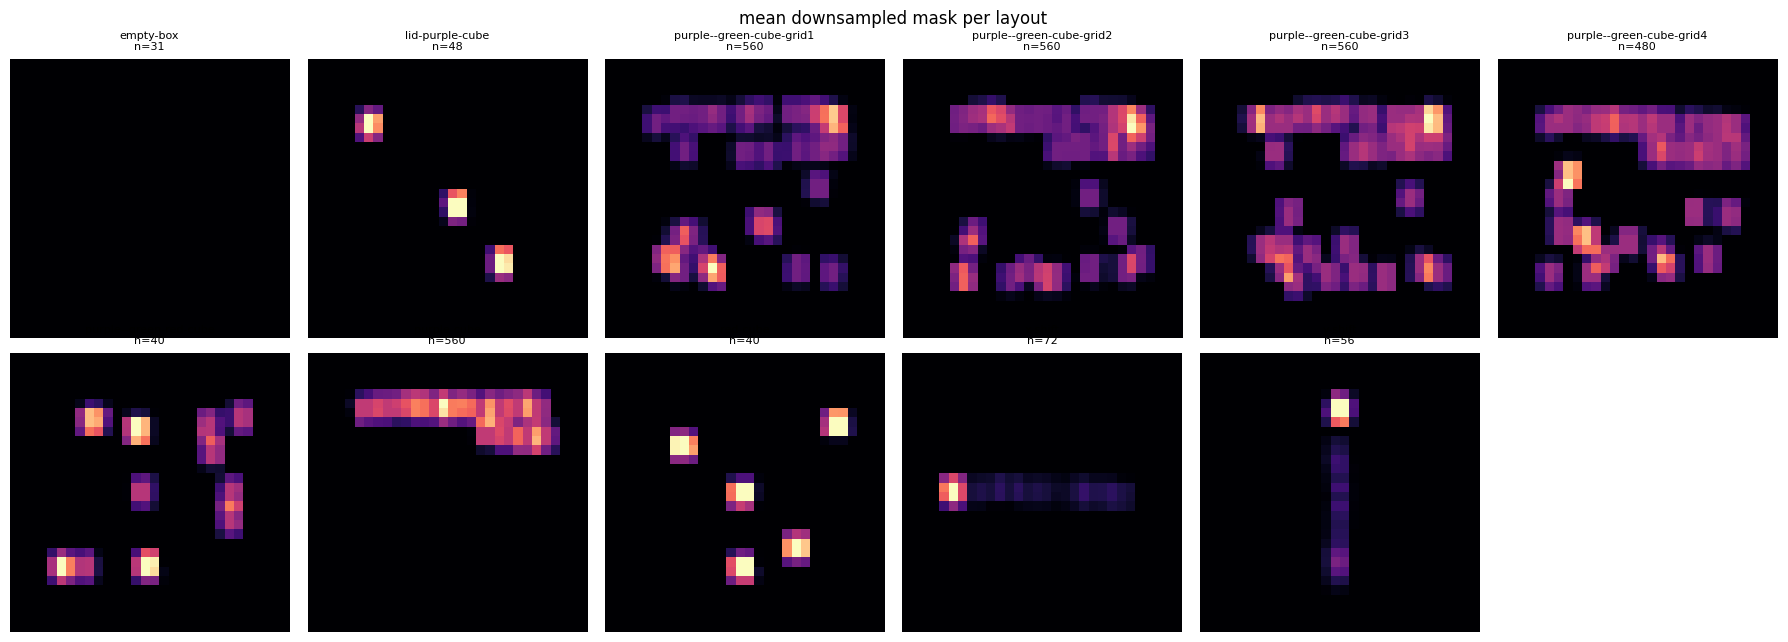

In [14]:
def mean_mask(sub, n=None):
    dirs = sub["dir"].tolist()[:n]
    return np.mean([np.load(d / f"images/04_downsampled_smask_{OUT_H}h_{OUT_W}w.npy") for d in dirs], axis=0)

layouts = sorted(df["layout"].unique())
fig, axes = plt.subplots(2, (len(layouts) + 1) // 2, figsize=(3 * ((len(layouts) + 1) // 2), 6.5))
for ax, lay in zip(axes.ravel(), layouts):
    sub = df[df.layout == lay]
    ax.imshow(mean_mask(sub, 120), vmin=0, cmap="magma")
    ax.set_title(f"{lay}\nn={len(sub)}", fontsize=8)
    ax.axis("off")
for ax in axes.ravel()[len(layouts):]: ax.axis("off")
plt.suptitle("mean downsampled mask per layout")
plt.tight_layout()

### A few individual (mask, mean-spectrum) pairs

Sanity check that non-empty samples look non-empty and that the spectra are not flat.

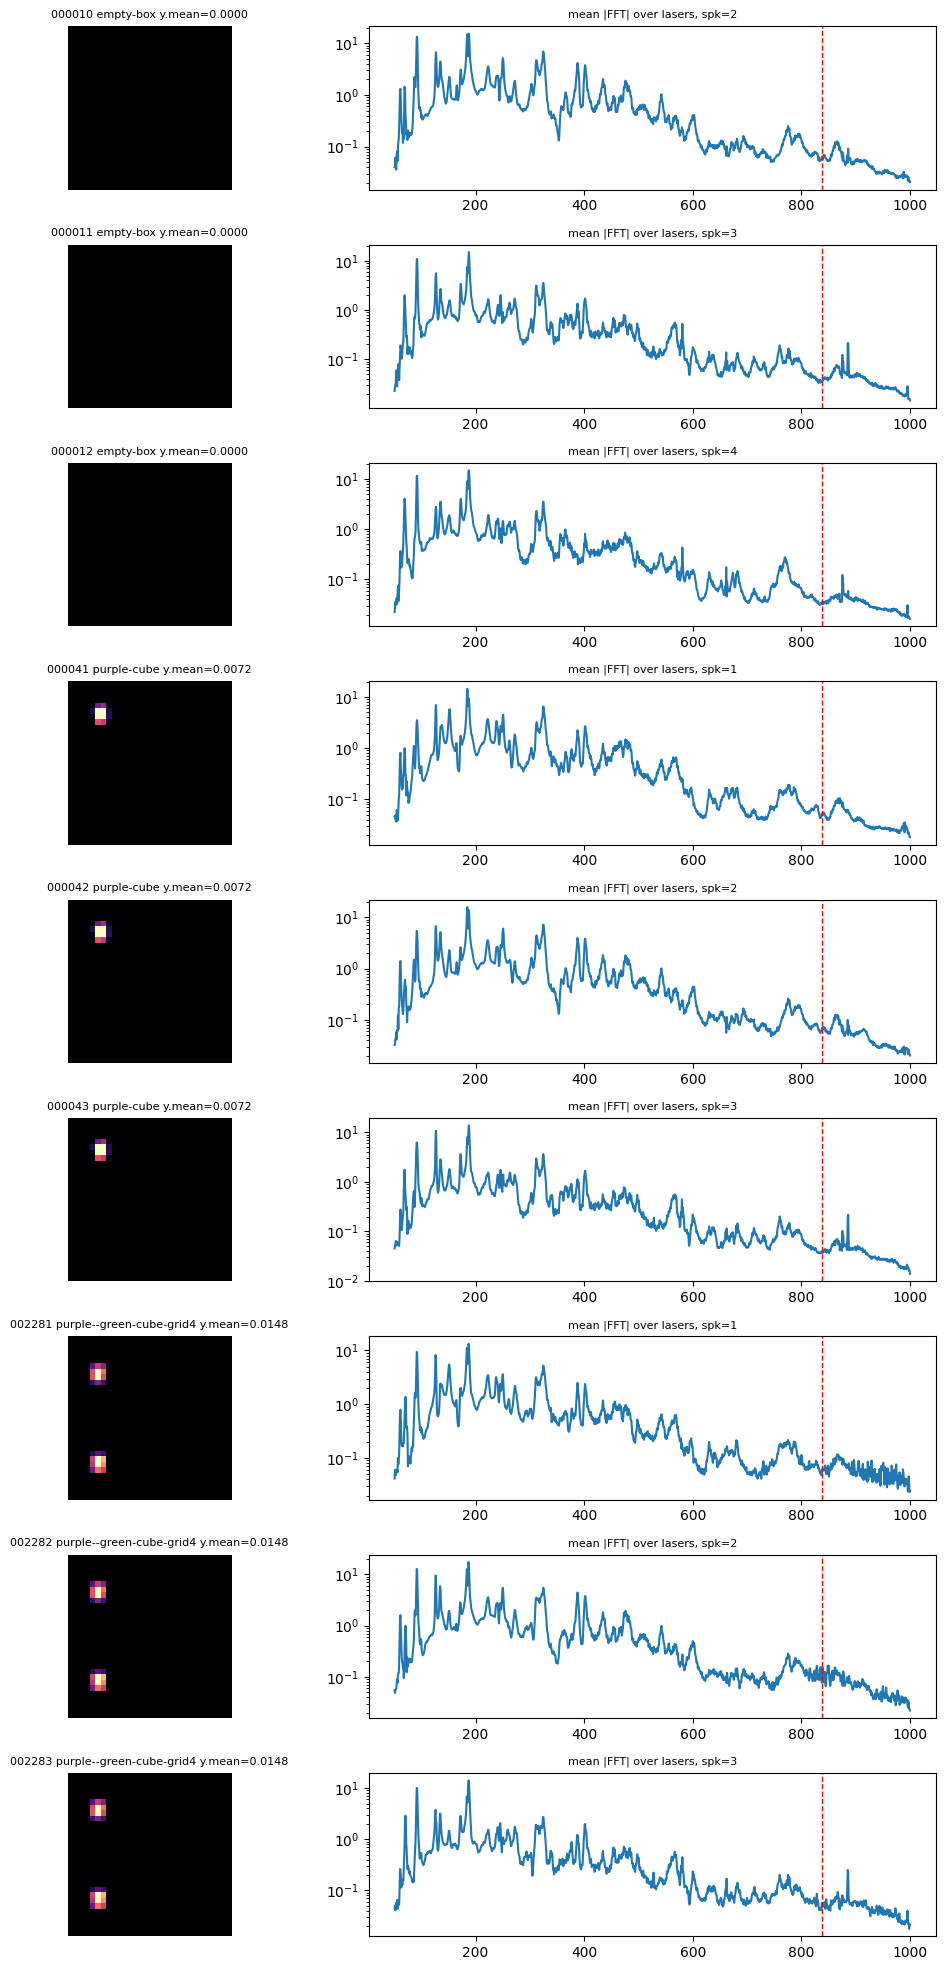

In [15]:
show = df[df.layout.isin(["empty-box", "purple-cube", "purple--green-cube-grid4"])].groupby("layout").head(3)
fig, axes = plt.subplots(len(show), 2, figsize=(11, 2.2 * len(show)))
for ax_row, (_, r) in zip(axes, show.iterrows()):
    y = np.load(r["dir"] / f"images/04_downsampled_smask_{OUT_H}h_{OUT_W}w.npy")
    d = np.load(r["dir"] / "vibration/03_fft.npz")
    fft = d["fft"][0] if d["fft"].ndim == 4 else d["fft"]
    ax_row[0].imshow(y, vmin=0, vmax=1, cmap="magma")
    ax_row[0].set_title(f"{r['sample_id']} {r['layout']} y.mean={y.mean():.4f}", fontsize=8)
    ax_row[0].axis("off")
    ax_row[1].semilogy(d["freqs"], np.abs(fft).mean(axis=(0, -1)))
    ax_row[1].set_title(f"mean |FFT| over lasers, spk={r['speaker']}", fontsize=8)
    ax_row[1].axvline(837.7, color="r", ls="--", lw=1)  # tokenize() truncation point
plt.tight_layout()

## 2. Splitting and MDS conversion

### 2a. Does the split assign every sample?

In [16]:
mds_dirs = sorted((DATA_DIR / "mds").glob("*"))
print("cached MDS builds:", [d.name for d in mds_dirs])
mds_dir = mds_dirs[0]

index = [json.loads(l) for l in (mds_dir / "metadata.jsonl").read_text().splitlines() if l.strip()]
print(f"{len(index)} rows in the MDS metadata sidecar")

splits = gastronorm(mds_dir, verbose=1)

cached MDS builds: ['8c805a44f335203d', 'a49dd5e4473775d8', 'fa2349ae68bdf8ab']


3007 rows in the MDS metadata sidecar


train: 2648 samples
eval/1-cube: 26 samples
eval/1-cube-speaker: 23 samples
eval/2-cubes: 96 samples
eval/2-cubes-speaker: 55 samples
eval/3-cubes: 40 samples
eval/red-cube: 40 samples


In [17]:
assigned = [i for v in splits.values() for i in v]
assigned_set = set(assigned)
print(f"total assignments : {len(assigned)}")
print(f"unique assigned   : {len(assigned_set)}   (duplicates: {len(assigned) - len(assigned_set)})")
print(f"NEVER assigned    : {len(index) - len(assigned_set)}")
print()
missing = [i for i in range(len(index)) if i not in assigned_set]
print("dropped-sample layouts:", Counter(index[i]["layout"] for i in missing))

total assignments : 2928
unique assigned   : 2928   (duplicates: 0)
NEVER assigned    : 79

dropped-sample layouts: Counter({'lid-purple-cube': 48, 'empty-box': 31})


### BUG 1 — `empty-box` never lands in any split

`gastronorm()` lists the always-train layouts as
`['empty', 'purple--green-cube-grid1', ..., 'x-shift', 'y-shift']`,
but the metadata's layout string is **`empty-box`**, not `empty`. The string never matches, so
every empty-box sample is silently dropped. `lid-purple-cube` is not listed at all and is
dropped too.

In [18]:
print("layout values in the data:")
for lay, n in Counter(r["layout"] for r in index).most_common(): print(f"  {lay:>28}: {n}")
print()
listed = ["empty", "purple--green-cube-grid1", "purple--green-cube-grid2",
          "purple--green-cube-grid3", "x-shift", "y-shift"]
data_layouts = set(r["layout"] for r in index)
print("listed in gastronorm() but ABSENT from the data:", [l for l in listed if l not in data_layouts])
print("in the data but handled by NO branch of gastronorm():",
      sorted(data_layouts - set(listed) - {"purple-cube", "purple--green-cube-grid4",
                                            "purple--green-red-cube", "red-cube"}))

layout values in the data:
                   purple-cube: 560
      purple--green-cube-grid1: 560
      purple--green-cube-grid2: 560
      purple--green-cube-grid3: 560
      purple--green-cube-grid4: 480
                       x-shift: 72
                       y-shift: 56
               lid-purple-cube: 48
        purple--green-red-cube: 40
                      red-cube: 40
                     empty-box: 31

listed in gastronorm() but ABSENT from the data: ['empty']
in the data but handled by NO branch of gastronorm(): ['empty-box', 'lid-purple-cube']


### BUG 2 — the filter in `gastronorm()` is computed then thrown away

```python
keep = [i for i, row in enumerate(index) if _matches(row, speakers, n_objects, box)]
if n_samples is not None: keep = keep[:n_samples]

lines = (Path(mds_path) / "metadata.jsonl").read_text().strip().splitlines()
index = [json.loads(line) for line in lines if line]   # <- index re-read, keep never used again
```

`keep` is never referenced after this, and `index` is re-read from disk (clobbering any `index`
passed in by the caller). So `--speakers`, `--n-objects`, `--box` and `--n-samples` are all
silently ignored on the `gastronorm` split. Verify:

In [19]:
a = gastronorm(mds_dir, verbose=0)
b = gastronorm(mds_dir, verbose=0, speakers=[1], n_samples=50)
print("filters have no effect:", {k: len(v) for k, v in a.items()} == {k: len(v) for k, v in b.items()})
print("unfiltered:", {k: len(v) for k, v in a.items()})
print("filtered  :", {k: len(v) for k, v in b.items()})

filters have no effect: True
unfiltered: {'train': 2648, 'eval/1-cube': 26, 'eval/1-cube-speaker': 23, 'eval/2-cubes': 96, 'eval/2-cubes-speaker': 55, 'eval/3-cubes': 40, 'eval/red-cube': 40}
filtered  : {'train': 2648, 'eval/1-cube': 26, 'eval/1-cube-speaker': 23, 'eval/2-cubes': 96, 'eval/2-cubes-speaker': 55, 'eval/3-cubes': 40, 'eval/red-cube': 40}


This also matters for `subtract_speaker_mean`, where `build_dataset` passes `index=` explicitly
and expects it to be honoured — it is discarded.

### BUG 3 — `output_id` and `downsampled_com` are absent, so MDS stores sentinels

`convert_to_mds` does `int(meta.get("output_id", -1))` and
`meta.get("downsampled_com", [-1.0, -1.0])`. This dataset's metadata has **`position_id`**, not
`output_id`, and no `downsampled_com` at all. Every MDS row therefore gets `output_id = -1` and
`com = (-1, -1)`.

In [20]:
from streaming import StreamingDataset

ds = StreamingDataset(local=str(mds_dir), shuffle=False)
r0 = ds[0]
print({k: (v.shape if isinstance(v, np.ndarray) else v) for k, v in r0.items()})
print()
oid = [ds[i]["output_id"] for i in range(0, len(ds), 200)]
com = [(ds[i]["downsampled_com_x"], ds[i]["downsampled_com_y"]) for i in range(0, len(ds), 200)]
print("output_id sample:", oid)
print("com sample      :", com)
print()
print("=> anything keyed on output_id (e.g. exp25_split, or downstream viz) sees a single")
print("   constant bucket. gastronorm() happens to use position_id from the sidecar instead,")
print("   so it survives -- but the MDS rows themselves carry no position information.")

{'X': (100, 1235, 2), 'box': 'gastronorm', 'downsampled_com_x': np.float64(-1.0), 'downsampled_com_y': np.float64(-1.0), 'is_empty_box': 1, 'n_objects': 0, 'object': '', 'output_id': -1, 'sample_id': 10, 'speaker': 2, 'y': (30, 30)}

output_id sample: [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]
com sample      : [(np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0)), (np.float64(-1.0), np.float64(-1.0))]

=> anything keyed on output_id (e.g. exp25_split, or do

### 2c. Does the MDS round-trip X and y faithfully?

Compare a handful of MDS rows against the on-disk source arrays.

In [21]:
by_sid = {r["sample_id"]: i for i, r in enumerate(index)}
checked = 0
for _, r in df.sample(8, random_state=0).iterrows():
    i = by_sid.get(r["sample_id"])
    if i is None:
        print(f"{r['sample_id']}: NOT IN MDS")
        continue
    row = ds[i]
    src_fft = np.load(r["dir"] / "vibration/03_fft.npz")["fft"]
    src_fft = src_fft[0] if src_fft.ndim == 4 else src_fft
    src_y = np.load(r["dir"] / f"images/04_downsampled_smask_{OUT_H}h_{OUT_W}w.npy")
    okx = np.array_equal(row["X"], src_fft)
    oky = np.allclose(row["y"], src_y)
    print(f"{r['sample_id']} idx={i:>5} X match={okx} y match={oky}  X{row['X'].shape} y{row['y'].shape}")
    checked += 1
print(f"\nchecked {checked}")

001839 idx= 1829 X match=True y match=False  X(100, 1235, 2) y(30, 30)
000371 idx=  361 X match=True y match=False  X(100, 1235, 2) y(30, 30)
001201 idx= 1191 X match=True y match=False  X(100, 1235, 2) y(30, 30)
002635 idx= 2625 X match=True y match=False  X(100, 1235, 2) y(30, 30)
002542 idx= 2532 X match=True y match=False  X(100, 1235, 2) y(30, 30)
002571 idx= 2561 X match=True y match=False  X(100, 1235, 2) y(30, 30)
000493 idx=  483 X match=True y match=False  X(100, 1235, 2) y(30, 30)
000316 idx=  306 X match=True y match=False  X(100, 1235, 2) y(30, 30)

checked 8


### 2d. MDS row order vs. sidecar order

`convert_to_mds` writes rows and `index_rows` in the same loop, so position `i` in the MDS must
be position `i` in `metadata.jsonl`. The split indexes the sidecar and hands those integers to
`Subset(dataset, idxs)` — if the orders ever diverged, every label would be attached to the
wrong signal. Verify directly.

In [22]:
mismatch = [i for i in range(0, len(ds), 37) if str(ds[i]["sample_id"]).zfill(6) != str(index[i]["sample_id"])]
print(f"order mismatches in {len(range(0, len(ds), 37))} probes: {len(mismatch)}")
print("first few MDS vs sidecar sample_ids:",
      [(ds[i]["sample_id"], index[i]["sample_id"]) for i in range(5)])

order mismatches in 82 probes: 0
first few MDS vs sidecar sample_ids: [(10, '000010'), (11, '000011'), (12, '000012'), (13, '000013'), (14, '000014')]


Note `sample_id` is written as `int(meta["sample_id"])`, so the MDS loses the zero-padding
(`"000010"` -> `10`). Harmless for training, but it breaks naive string joins against the
sample directories.

### 2e. Train/eval leakage by position

`split_by_position` holds out whole `position_id`s. But `position_id` is only unique *within* a
layout — check whether the same id is reused across layouts, which would make the "unseen
position" eval sets not actually unseen.

In [23]:
idf = pd.DataFrame(index)
print("position_id ranges per layout:")
print(idf.groupby("layout")["position_id"].agg(["min", "max", "nunique", "count"]))
print()
print("unique position_id values overall :", idf.position_id.nunique())
print("unique (layout, position_id) pairs:", idf.groupby(['layout', 'position_id']).ngroups)

position_id ranges per layout:
                          min  max  nunique  count
layout                                            
empty-box                   2    5        4     31
lid-purple-cube           356  361        6     48
purple--green-cube-grid1   76  145       70    560
purple--green-cube-grid2  146  215       70    560
purple--green-cube-grid3  216  285       70    560
purple--green-cube-grid4  286  345       60    480
purple--green-red-cube    346  350        5     40
purple-cube                 6   75       70    560
red-cube                  351  355        5     40
x-shift                   362  370        9     72
y-shift                   371  377        7     56

unique position_id values overall : 376
unique (layout, position_id) pairs: 376


In [24]:
train_pos = {(index[i]["layout"], index[i]["position_id"]) for i in splits["train"]}
for name in ["eval/1-cube", "eval/2-cubes"]:
    ev = {(index[i]["layout"], index[i]["position_id"]) for i in splits[name]}
    print(f"{name:>14}: {len(ev)} positions, {len(ev & train_pos)} also in train  <- should be 0")
for name in ["eval/1-cube-speaker", "eval/2-cubes-speaker"]:
    ev = {(index[i]["layout"], index[i]["position_id"]) for i in splits[name]}
    print(f"{name:>14}: {len(ev)} positions, {len(ev & train_pos)} also in train  <- should equal the first number")

   eval/1-cube: 12 positions, 12 also in train  <- should be 0
  eval/2-cubes: 12 positions, 0 also in train  <- should be 0
eval/1-cube-speaker: 21 positions, 21 also in train  <- should equal the first number
eval/2-cubes-speaker: 33 positions, 33 also in train  <- should equal the first number


### 2f. What the model actually trains on

Composition of the train split — this is what determines what "predict nothing" costs.

In [25]:
tr = idf.iloc[splits["train"]]
print("train layouts:"); print(tr.layout.value_counts())
print()
print("train n_objects:"); print(tr.n_objects.value_counts())
print()
print("=> no empty-box samples in train (BUG 1), and n_objects is never 0.")

train layouts:
layout
purple--green-cube-grid1    560
purple--green-cube-grid2    560
purple--green-cube-grid3    560
purple-cube                 511
purple--green-cube-grid4    329
x-shift                      72
y-shift                      56
Name: count, dtype: int64

train n_objects:
n_objects
2    2137
1     511
Name: count, dtype: int64

=> no empty-box samples in train (BUG 1), and n_objects is never 0.


### 2g. FFT truncation in `tokenize`

`tokenize` keeps `(F // patch_size) * patch_size` bins and drops the remainder.

In [26]:
n_freqs = int(df.n_freqs.iloc[0])
freqs = np.load(df["dir"].iloc[0] / "vibration/03_fft.npz")["freqs"]
kept = (n_freqs // PATCH_SIZE) * PATCH_SIZE
print(f"n_freqs={n_freqs}, patch_size={PATCH_SIZE} -> {n_freqs // PATCH_SIZE} patches, {kept} bins kept")
print(f"DROPPED {n_freqs - kept} bins = {freqs[kept]:.1f} Hz .. {freqs[-1]:.1f} Hz")
print(f"chirp band is {df.min_freq.iloc[0]}..{df.max_freq.iloc[0]} Hz, so the top "
      f"{(freqs[-1] - freqs[kept]) / (freqs[-1] - freqs[0]):.0%} of the excitation is discarded.")

n_freqs=1235, patch_size=256 -> 4 patches, 1024 bins kept
DROPPED 211 bins = 838.5 Hz .. 1000.0 Hz
chirp band is 50..1000 Hz, so the top 17% of the excitation is discarded.


## 3. Compare against `experiment-25`, which *did* train

The decisive comparison. exp25 uses an older on-disk layout (`image/` singular,
`02_smask.png`, `05_downsampled_*`), so we recompute both from the full-resolution masks with
the same `downsample_mask` to make them directly comparable.

In [27]:
EXP25_DIR = Path.cwd().parent / "experiments" / "experiment-25"

SCHEMES = {
    "experiment-25 (works)": dict(root=EXP25_DIR, smask="image/02_smask.png", fft="vibration/03_fft.npz"),
    "gastronorm (broken)":   dict(root=DATA_DIR,  smask="images/03_smask.png", fft="vibration/03_fft.npz"),
}

def scheme_dirs(s):
    # require both the mask and the fft -- gastronorm has one incomplete sample (000009)
    return [d for d in sorted((s["root"] / "samples").glob("*"))
            if (d / s["smask"]).exists() and (d / s["fft"]).exists()]

for name, s in SCHEMES.items():
    print(f"{name:>22}: {len(scheme_dirs(s))} samples with a mask, root={s['root'].name}")

 experiment-25 (works): 1024 samples with a mask, root=experiment-25
   gastronorm (broken): 3007 samples with a mask, root=31_07_2026_gastronorm_exp1


### 3a. Mask occupancy — the headline difference

In [28]:
from PIL import Image
from model.dataset import downsample_mask

import random
rng = random.Random(0)
occ = []
for name, s in SCHEMES.items():
    dirs = scheme_dirs(s)
    sel = rng.sample(dirs, min(200, len(dirs)))
    full = Image.open(sel[0] / s["smask"]).size
    ys = np.array([downsample_mask(Image.open(d / s["smask"]), OUT_H, OUT_W) for d in sel])
    occ.append({
        "dataset": name, "n_sampled": len(sel), "full_res": full,
        "y_mean": ys.mean(), "E[y^2]": np.mean(ys ** 2),
        "frac_nonzero": np.mean(ys > 0),
        "std_across_samples": ys.mean(axis=(1, 2)).std(),
    })
occ_df = pd.DataFrame(occ).set_index("dataset")
occ_df

,n_sampled,full_res,y_mean,E[y^2],frac_nonzero,std_across_samples
dataset,,,,,,
experiment-25 (works),200,"(679, 309)",0.071962,0.064878,0.094178,0.024349
gastronorm (broken),200,"(1337, 1110)",0.013648,0.010400,0.025656,0.004907


In [29]:
r = occ_df["y_mean"]
print(f"exp25 occupancy is {r.iloc[0] / r.iloc[1]:.1f}x that of gastronorm")
print()
print("all-zero-predictor MSE:")
for name, row in occ_df.iterrows():
    print(f"  {name:>22}: {row['E[y^2]']:.5f}")
print()
print("The gastronorm full-resolution frame is much larger (see full_res) while the cubes are the")
print("same physical size, so after downsampling to a 30x30 grid the objects cover ~1.4% of the")
print("cells instead of ~7.3%. That is the regime where the all-zero solution wins under MSE.")

exp25 occupancy is 5.3x that of gastronorm

all-zero-predictor MSE:
   experiment-25 (works): 0.06488
     gastronorm (broken): 0.01040

The gastronorm full-resolution frame is much larger (see full_res) while the cubes are the
same physical size, so after downsampling to a 30x30 grid the objects cover ~1.4% of the
cells instead of ~7.3%. That is the regime where the all-zero solution wins under MSE.


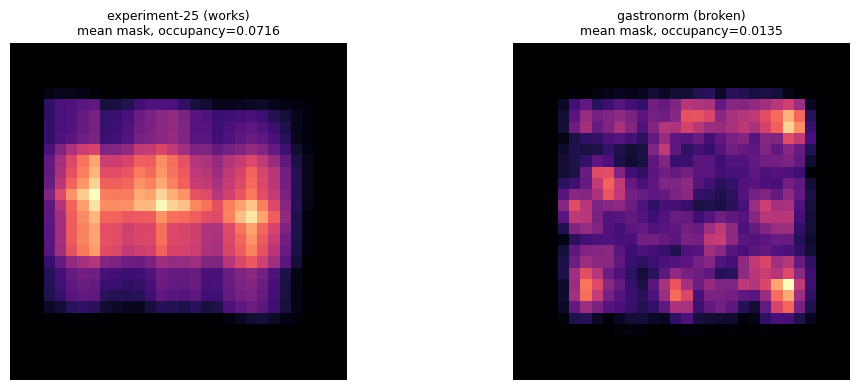

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, s) in zip(axes, SCHEMES.items()):
    dirs = scheme_dirs(s)
    sel = rng.sample(dirs, min(200, len(dirs)))
    ys = np.array([downsample_mask(Image.open(d / s["smask"]), OUT_H, OUT_W) for d in sel])
    ax.imshow(ys.mean(axis=0), cmap="magma")
    ax.set_title(f"{name}\nmean mask, occupancy={ys.mean():.4f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

### 3b. Metadata schema drift between the two datasets

This is the root cause of bugs 1 and 3 — `dataset.py` was written against exp25's schema and
the gastronorm capture emits different key names and layout strings.

In [31]:
def meta_of(d):
    return {k: v for l in open(d / "metadata.jsonl") for k, v in json.loads(l).items()}

m25 = meta_of(scheme_dirs(SCHEMES["experiment-25 (works)"])[0])
mgn = meta_of(scheme_dirs(SCHEMES["gastronorm (broken)"])[0])

keys = sorted(set(m25) | set(mgn))
schema = pd.DataFrame({
    "key": keys,
    "exp25": ["yes" if k in m25 else "-" for k in keys],
    "gastronorm": ["yes" if k in mgn else "-" for k in keys],
})
print("keys that DIFFER between the two:")
print(schema[schema.exp25 != schema.gastronorm].to_string(index=False))

keys that DIFFER between the two:
                key exp25 gastronorm
           audio_fs     -        yes
  buffer_part_count     -        yes
     experiment_dir     -        yes
             expose     -        yes
               gain     -        yes
laser_beam_splitter   yes          -
  laser_grid_bounds   yes          -
          laser_idx     -        yes
             n_cols     -        yes
           n_frames     -        yes
       n_laser_cols   yes          -
       n_laser_rows   yes          -
           n_lasers   yes          -
             n_rows     -        yes
         output_dir   yes          -
          output_id   yes          -
         patch_size   yes          -
    pclk_batch_size     -        yes
        position_id     -        yes
              power     -        yes
      resize_params   yes          -
                roi   yes          -
               rois     -        yes
         sample_dir   yes          -
        seg_results     -        yes
    

In [32]:
for k in ["output_id", "position_id", "downsampled_com", "object", "layout", "n_objects"]:
    print(f"{k:>18}: exp25={m25.get(k)!r:<20} gastronorm={mgn.get(k)!r}")
print()
print("=> exp25 has output_id (which convert_to_mds and exp25_split both use);")
print("   gastronorm has position_id instead, so output_id silently becomes -1.")

         output_id: exp25='000000'             gastronorm=None
       position_id: exp25=None                 gastronorm=2
   downsampled_com: exp25=None                 gastronorm=None
            object: exp25=None                 gastronorm=None
            layout: exp25='empty-box'          gastronorm='empty-box'
         n_objects: exp25=0                    gastronorm=0

=> exp25 has output_id (which convert_to_mds and exp25_split both use);
   gastronorm has position_id instead, so output_id silently becomes -1.


In [33]:
def layouts_of(s):
    return Counter(meta_of(d).get("layout") for d in scheme_dirs(s))

for name, s in SCHEMES.items():
    print(f"\n{name} layouts:")
    for lay, n in layouts_of(s).most_common(): print(f"  {lay!r:>32}: {n}")


experiment-25 (works) layouts:
                     'purple-cube': 456
          'purple-cube-green-cube': 400
                      'green-cube': 144
                       'empty-box': 24

gastronorm (broken) layouts:


                     'purple-cube': 560
        'purple--green-cube-grid1': 560
        'purple--green-cube-grid2': 560
        'purple--green-cube-grid3': 560
        'purple--green-cube-grid4': 480
                         'x-shift': 72
                         'y-shift': 56
                 'lid-purple-cube': 48
          'purple--green-red-cube': 40
                        'red-cube': 40
                       'empty-box': 31


### 3c. FFT resolution differs too

exp25 has 2946 frequency bins; gastronorm has 1235 over the same 50–1000 Hz chirp. That changes
how `tokenize`'s truncation bites (see §2g and §4).

In [34]:
fft_cmp = []
for name, s in SCHEMES.items():
    d = scheme_dirs(s)[0]
    z = np.load(d / s["fft"])
    fft = z["fft"][0] if z["fft"].ndim == 4 else z["fft"]
    fr = z["freqs"]
    kept = (fft.shape[1] // PATCH_SIZE) * PATCH_SIZE
    fft_cmp.append({
        "dataset": name, "shape": fft.shape, "n_freqs": len(fr),
        "f_min": fr.min(), "f_max": fr.max(),
        "n_patches": fft.shape[1] // PATCH_SIZE,
        "bins_kept": kept, "bins_dropped": fft.shape[1] - kept,
        "hz_dropped_above": fr[kept] if kept < len(fr) else None,
    })
pd.DataFrame(fft_cmp).set_index("dataset")

,shape,n_freqs,f_min,f_max,n_patches,bins_kept,bins_dropped,hz_dropped_above
dataset,,,,,,,,
experiment-25 (works),"(100, 2946, 2)",2946,50.000000,1000.0,11,2816,130,958.387097
gastronorm (broken),"(100, 1235, 2)",1235,50.769231,1000.0,4,1024,211,838.461538


## 4. Padding the FFT instead of truncating it

`tokenize` currently does `x[:, :, :P * patch_size, :]`, throwing away the tail. On gastronorm
that is 211 bins = 838–1000 Hz, the top of the excitation band. Rather than discard them, pad up
to the next whole patch and mask the padded positions out of attention so the model never
computes over them.

Below: a padding `tokenize` plus the boolean mask it needs. This is a proposal — nothing in
`model/` is modified by this notebook.

In [35]:
import torch

def tokenize_pad(x: torch.Tensor, patch_size: int) -> tuple[torch.Tensor, torch.Tensor]:
    """(B,L,F,C) -> ((B,L,P,PS,C), valid mask (P*PS,) True where real).

    Zero-pads F up to a whole number of patches instead of truncating. The returned mask marks
    which frequency positions are real so the caller can exclude the padding from attention and
    from any per-frequency reduction.
    """
    if patch_size <= 0: return x, torch.ones(x.shape[2], dtype=torch.bool, device=x.device)
    B, L, F_, C = x.shape
    P = (F_ + patch_size - 1) // patch_size          # ceil, not floor
    pad = P * patch_size - F_
    if pad: x = torch.nn.functional.pad(x, (0, 0, 0, pad))   # pads the F axis, last-dim-first order
    valid = torch.zeros(P * patch_size, dtype=torch.bool, device=x.device)
    valid[:F_] = True
    return x.reshape(B, L, P, patch_size, C), valid

In [36]:
from model.dataset import tokenize as tokenize_trunc

d = np.load(df["dir"].iloc[0] / "vibration/03_fft.npz")
fft = d["fft"][0] if d["fft"].ndim == 4 else d["fft"]
x = torch.from_numpy(np.abs(fft)).unsqueeze(0).float()   # (1,L,F,C)

old = tokenize_trunc(x, PATCH_SIZE)
new, valid = tokenize_pad(x, PATCH_SIZE)
print(f"input          : {tuple(x.shape)}   ({x.shape[2]} freq bins)")
print(f"truncating     : {tuple(old.shape)}  -> {old.shape[2] * old.shape[3]} bins, {x.shape[2] - old.shape[2] * old.shape[3]} DISCARDED")
print(f"padding        : {tuple(new.shape)}  -> {new.shape[2] * new.shape[3]} slots, {valid.sum().item()} real / {(~valid).sum().item()} padding")
print()
print(f"real bins preserved exactly: "
      f"{torch.allclose(new.reshape(1, x.shape[1], -1, x.shape[3])[:, :, valid], x)}")
print(f"padding is zero            : {new.reshape(1, x.shape[1], -1, x.shape[3])[:, :, ~valid].abs().max().item() == 0}")

input          : (1, 100, 1235, 2)   (1235 freq bins)
truncating     : (1, 100, 4, 256, 2)  -> 1024 bins, 211 DISCARDED
padding        : (1, 100, 5, 256, 2)  -> 1280 slots, 1235 real / 45 padding

real bins preserved exactly: True
padding is zero            : True


### What has to change downstream

Padding adds a 5th patch that is 82% zeros. Feeding it in unmasked would let the model attend to
constant-zero tokens and would shift any mean/std computed over the frequency axis. Concretely:

1. **`normalize_fft` must run before padding** (it already does — `process_vibration` normalizes
   then tokenizes), otherwise the zeros drag the std down by ~10%.
2. **`data_info["n_freqs"]`** in `run.py` is computed as `n_patches * patch_size`; with padding
   that becomes 1280 rather than 1024, which is the correct positional-embedding length.
3. **The frequency-axis attention in `VibrationTransformer` needs the `valid` mask** as a key
   padding mask, so the padded slots contribute nothing.

Check what the model currently does with the frequency axis:

In [37]:
# read as text rather than importing -- arch.py pulls in `utils`, which lives outside src/
src = (Path.cwd().parent / "src" / "model" / "arch.py").read_text()
for kw in ["n_freqs", "key_padding_mask", "patch", "attn_mask"]:
    hits = [f"  {i}: {l.strip()}" for i, l in enumerate(src.splitlines(), 1) if kw in l]
    print(f"--- {kw!r} ({len(hits)} hits)")
    print("\n".join(hits[:8]))

--- 'n_freqs' (1 hits)
  214: self.freq_encoder = FreqEncoder(data_info['patch_size'], d_model, pnt_num_heads, pnt_num_layers, data_info['n_freqs'], freq_dropout, n_channels=data_info.get('n_channels', 2))
--- 'key_padding_mask' (7 hits)
  157: def forward(self, memory, memory_key_padding_mask=None):
  162: out = self.layers(queries, memory, memory_key_padding_mask=memory_key_padding_mask)  # (B,out_h*out_w,D)
  180: """(B,L) keep mask -> (B,L+1) key_padding_mask (True = ignore), with the prepended cls token never masked."""
  204: output = self.layers(x, src_key_padding_mask=pad_mask(keep, B_L)) # (B_L,P+1,D) -> (B_L,P+1,D)
  240: key_padding_mask = pad_mask(keep, B)  # (B,L+1), True = ignore; None if not dropping
  245: output = self.laser_encoder(x, src_key_padding_mask=key_padding_mask)  # (B,L+1,D) -> (B,L+1,D)
  249: mask_logits = self.decoder(decoder_input, key_padding_mask) if isinstance(self.decoder, AttnDecoder) else self.decoder(decoder_input) # (B,L+1,D) or (B,D) -> (B,H,W)

**The cheaper alternative**: `1235 = 5 * 247`, so `--patch-size 247` tiles the band exactly with
no padding and no truncation, at the cost of a patch size that differs from exp25's 256. If the
goal is only "stop throwing away 838–1000 Hz", that is a one-flag change and needs no masking
support in the model at all.

In [38]:
n = int(df.n_freqs.iloc[0])
print(f"n_freqs = {n}")
print("exact divisors that give a sane patch count:")
for ps in range(64, 641):
    if n % ps == 0: print(f"  patch_size={ps:>4} -> {n // ps} patches, no padding, no truncation")

n_freqs = 1235
exact divisors that give a sane patch count:
  patch_size=  65 -> 19 patches, no padding, no truncation
  patch_size=  95 -> 13 patches, no padding, no truncation
  patch_size= 247 -> 5 patches, no padding, no truncation


## Summary

**Why the model predicts nothingness**

**The primary cause is mask sparsity, and the exp25 comparison pins it down.**

| | experiment-25 (trains) | gastronorm (predicts nothing) |
|---|---|---|
| full-res mask | 679 x 309 | 1337 x 1110 |
| occupancy at 30x30 | ~7.3% | ~1.4% |
| all-zero MSE `E[y^2]` | ~0.065 | ~0.011 |

The gastronorm frame is much larger while the cubes stay the same physical size, so after
downsampling the objects cover **5.2x fewer cells**. Under MSE the all-zero predictor scores
`E[y^2] ≈ 0.011`, essentially tying the best constant predictor — a very deep local optimum that
exp25's 7.3% occupancy was dense enough to escape. Fixes, in order of leverage: reweight the
positive class (dice / focal / BCE with `pos_weight` — check `LOSSES` in `model/arch.py`), or
crop the overhead image to the box before downsampling so occupancy matches exp25.

**Real bugs found in the pipeline** (all from schema drift vs. exp25, see §3b)

1. `gastronorm()` matches the layout `'empty'` but the data says `'empty-box'` — all empty-box
   samples (and all `lid-purple-cube` samples) are silently dropped from every split. The model
   never sees a single empty box, so it has no calibration for "no object here".
2. `gastronorm()` computes `keep` from the filters, then re-reads `index` from disk and never
   uses `keep` again. `speakers` / `n_objects` / `box` / `n_samples` are all no-ops, and the
   `index=` argument that `build_dataset` passes for `subtract_speaker_mean` is discarded.
3. The metadata has `position_id`, not exp25's `output_id`, and no `downsampled_com`, so every
   MDS row stores `output_id = -1` and `com = (-1, -1)`.
4. **`eval/1-cube` is not actually an unseen-position set.** All 12 of its positions also appear
   in train (§2e) — `eval/2-cubes` correctly has 0. Cause: `gastronorm()` calls `train_test_split`
   on the `purple-cube` rows *first*, then runs `split_by_position` only on the 20% eval side, so
   a position held out there can still be present in the 80% already sent to train.
   `split_by_position` must run on the whole layout, as it does for two-cubes.
5. `tokenize` silently discards the top 211 bins (838–1000 Hz) at `patch_size=256`. §4 gives a
   padding `tokenize_pad` that keeps them plus the `valid` mask the model would need — or just
   pass `--patch-size 247`, which divides 1235 exactly and needs no model change.

**One more thing worth watching** (§1): speaker explains **99%** of the between-sample variance
in `raw_mag_mean`, vs 0.3% for layout and 0.7% for position. The dominant axis of variation in
the signal is which speaker played, not where the cubes are. `--subtract-speaker-mean 1` exists
for exactly this and is off by default.